In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install groq

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle, time, os
from dotenv import load_dotenv

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

load_dotenv()
pd.set_option('display.max_columns', None)

In [5]:
train_df = pd.read_parquet('../data/processed/train.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')

X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']
X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (5634, 30) | Test: (1409, 30)


In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: entrenado ✓")

Logistic Regression: entrenado ✓
Random Forest: entrenado ✓
Gradient Boosting: entrenado ✓


In [7]:
def evaluar_modelo(model, X_test, y_test, nombre):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba)
    }

resultados = [evaluar_modelo(m, X_test, y_test, n) for n, m in models.items()]
resultados_df = pd.DataFrame(resultados)
resultados_df

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842179
1,Random Forest,0.786373,0.622074,0.497326,0.552749,0.824886
2,Gradient Boosting,0.797729,0.653979,0.505348,0.570136,0.841654


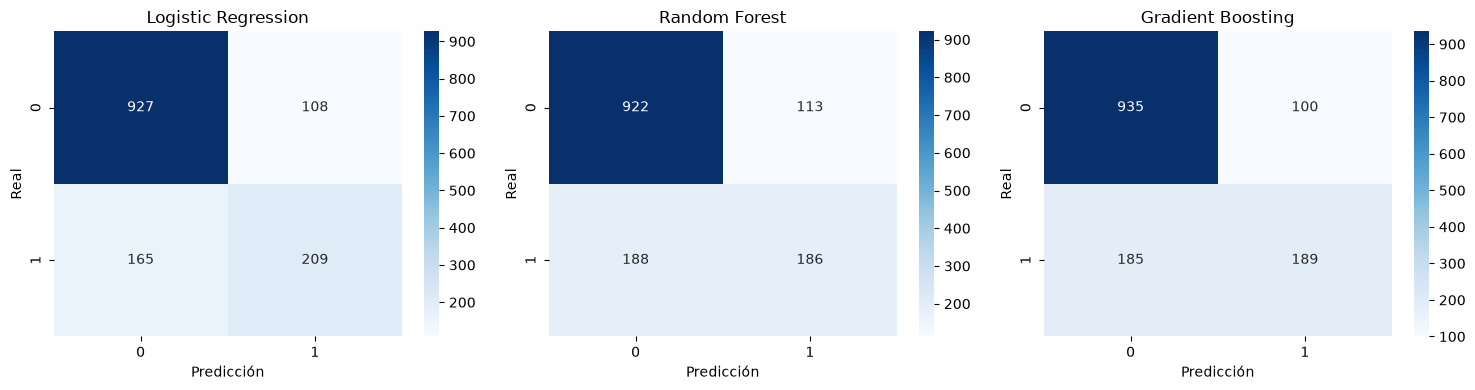

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('../artifacts/matrices_confusion.png')
plt.show()

In [9]:
print("Validación cruzada (5-fold) - F1 score:")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Validación cruzada (5-fold) - F1 score:
Logistic Regression: 0.5986 (+/- 0.0280)
Random Forest: 0.5455 (+/- 0.0222)
Gradient Boosting: 0.5705 (+/- 0.0280)


In [10]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1
)

rf_search.fit(X_train, y_train)
print(f"Mejores parámetros: {rf_search.best_params_}")
print(f"Mejor F1 (CV): {rf_search.best_score_:.4f}")

Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced'}
Mejor F1 (CV): 0.6302


In [11]:
best_model = rf_search.best_estimator_

resultado_final = evaluar_modelo(best_model, X_test, y_test, 'Random Forest (tuned)')
resultados.append(resultado_final)
resultados_df = pd.DataFrame(resultados)

resultados_df.to_csv('../artifacts/resultados_metricas.csv', index=False)

with open('../artifacts/modelo.pkl', 'wb') as f:
    pickle.dump(best_model, f)

resultados_df

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842179
1,Random Forest,0.786373,0.622074,0.497326,0.552749,0.824886
2,Gradient Boosting,0.797729,0.653979,0.505348,0.570136,0.841654
3,Random Forest (tuned),0.754436,0.525547,0.770053,0.624729,0.841373


In [12]:
n_samples = 100
sample = X_test.sample(n_samples, random_state=42)

start = time.time()
for i in range(len(sample)):
    best_model.predict(sample.iloc[[i]])
end = time.time()

latencia_ms = ((end - start) / n_samples) * 1000
throughput = n_samples / (end - start)

print(f"Latencia promedio por predicción: {latencia_ms:.2f} ms")
print(f"Throughput: {throughput:.1f} predicciones/segundo")

pd.DataFrame([
    {'Metrica': 'Latencia promedio (ms)', 'Valor': round(latencia_ms, 2)},
    {'Metrica': 'Throughput (pred/seg)', 'Valor': round(throughput, 1)}
]).to_csv('../artifacts/resultados_online.csv', index=False)

Latencia promedio por predicción: 22.77 ms
Throughput: 43.9 predicciones/segundo


In [13]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

##shap_values_churn = shap_values[1] if isinstance(shap_values, list) else shap_values
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_churn = shap_values[:, :, 1]
else:
    shap_values_churn = shap_values

importancia_global = pd.DataFrame({
    'feature': X_test.columns,
    'importancia': np.abs(shap_values_churn).mean(axis=0)
}).sort_values('importancia', ascending=False)

importancia_global.head(10)

C:\Users\cardo\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,importancia
1,tenure,0.072075
25,Contract_Two year,0.064047
10,InternetService_Fiber optic,0.062217
3,TotalCharges,0.037867
28,PaymentMethod_Electronic check,0.033632
24,Contract_One year,0.031858
2,MonthlyCharges,0.027570
13,OnlineSecurity_Yes,0.025856
19,TechSupport_Yes,0.019162
26,PaperlessBilling_Yes,0.016126


In [14]:
fig = px.bar(importancia_global.head(10), x='importancia', y='feature',
              orientation='h', title='Top 10 variables más importantes (SHAP)')
fig.write_html('../artifacts/shap_importancia_global.html')
fig.show()

In [15]:
from groq import Groq

customers_clean = pd.read_csv('../data/processed/customers_clean.csv')
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

In [21]:
def explicar_cliente(pos, X_test, shap_values_churn, top_n=4):
    shap_row = shap_values_churn[int(pos)]
    return pd.DataFrame({
        'feature': X_test.columns,
        'shap_value': shap_row
    }).sort_values('shap_value', key=abs, ascending=False).head(top_n)

In [22]:
def generar_explicacion_llm(prediccion, probabilidad, top_features, customer_info):
    factores = "\n".join([
        f"- {row['feature']}: influencia = {row['shap_value']:.3f}"
        for _, row in top_features.iterrows()
    ])

    prompt = f"""Eres un analista de retención de clientes. Genera una explicación breve
(3-4 oraciones) en español, dirigida a un equipo de negocio (no técnico), sobre por qué
el modelo predice que este cliente tiene {'ALTO' if prediccion == 1 else 'BAJO'} riesgo
de cancelar el servicio (probabilidad de churn: {probabilidad:.1%}).

Datos del cliente:
- Tipo de contrato: {customer_info['Contract']}
- Antigüedad (meses): {customer_info['tenure']}
- Cargo mensual: ${customer_info['MonthlyCharges']}
- Servicio de internet: {customer_info['InternetService']}
- Método de pago: {customer_info['PaymentMethod']}

Factores con mayor influencia según el modelo:
{factores}

No menciones términos técnicos como "SHAP" o "modelo". Explica en lenguaje de negocio
y, si aplica, sugiere una acción de retención."""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=300
    )
    return response.choices[0].message.content

In [23]:
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = best_model.predict(X_test)

resultados_pred = pd.DataFrame({
    'idx': X_test.index,
    'pos': range(len(X_test)),
    'prediccion': y_pred_test,
    'probabilidad': y_proba_test,
    'real': y_test.values
})

alto_riesgo = resultados_pred.sort_values('probabilidad', ascending=False).head(2)
bajo_riesgo = resultados_pred.sort_values('probabilidad', ascending=True).head(2)
ejemplos = pd.concat([alto_riesgo, bajo_riesgo])
ejemplos

,idx,pos,prediccion,probabilidad,real
1221,1221,1221,1,0.952258,1
1109,1109,1109,1,0.948946,1
1344,1344,1344,0,0.000196,0
92,92,92,0,0.000196,0


In [24]:
explicaciones = []

for _, row in ejemplos.iterrows():
    customer_info = customers_clean.loc[row['idx']]
    top_feats = explicar_cliente(row['pos'], X_test, shap_values_churn)

    explicacion = generar_explicacion_llm(
        prediccion=row['prediccion'],
        probabilidad=row['probabilidad'],
        top_features=top_feats,
        customer_info=customer_info
    )

    explicaciones.append({
        'customerID': customer_info['customerID'],
        'prediccion': 'Churn' if row['prediccion'] == 1 else 'No Churn',
        'probabilidad': round(row['probabilidad'], 3),
        'real': 'Churn' if row['real'] == 1 else 'No Churn',
        'explicacion_llm': explicacion
    })

explicaciones_df = pd.DataFrame(explicaciones)

explicaciones_df.to_csv('../artifacts/explicaciones_llm.csv', index=False)
explicaciones_df.to_html('../artifacts/explicaciones_llm.html', index=False)

for _, row in explicaciones_df.iterrows():
    print(f"\n{'='*60}")
    print(f"Cliente {row['customerID']} | Predicción: {row['prediccion']} ({row['probabilidad']:.1%}) | Real: {row['real']}")
    print('-'*60)
    print(row['explicacion_llm'])


Cliente 3055-MJDSB | Predicción: Churn (95.2%) | Real: Churn
------------------------------------------------------------
Nuestro análisis indica que este cliente tiene un alto riesgo de cancelar el servicio, con una probabilidad del 95.2%. Esto se debe principalmente a que el cliente tiene un contrato mensual y solo tiene 9 meses de antigüedad, lo que sugiere que no tiene un compromiso a largo plazo con nuestra empresa. Además, el hecho de que no tenga un servicio de internet de alta velocidad como la fibra óptica también influye en esta predicción. Para reducir el riesgo de pérdida de este cliente, podríamos considerar ofrecerle un upgrade a un servicio de internet más rápido y confiable, como la fibra óptica, o incluso ofrecerle un contrato de dos años con beneficios exclusivos para fomentar su lealtad.

Cliente 3391-JSQEW | Predicción: Churn (94.9%) | Real: Churn
------------------------------------------------------------
Nuestro análisis sugiere que este cliente tiene un alto ri